<h1><center>LSTM-based MODELS</center></h1>

**I. LIBRARIES**  

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
import os
import datetime
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Conv1D
from keras.layers import MaxPooling1D
from keras.layers import Flatten
from keras.layers import Dropout
from keras.layers import RepeatVector
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

print("Num GPUs Available: ", len(tf.config.list_physical_devices("GPU")))
# fix random seed for reproducibility
tf.random.set_seed(8)

Num GPUs Available:  0


## II. HYPERPARAMETERS

* Saved models for later review *(only saved models run with new data)*:
    * LSTM: 14, 16, 17
    * LSTM_DNN: 
    * LSTM_CNN: 15
    * CNN: 

### LSTM-based

In [2]:
# Hyperparameter for LSTM
TRAIN_TEST_RATIO = 0.8
TIME_STEP = 20
MODEL_TYPE = "LSTM"
EPOCH_SIZE = 1000
BATCH_SIZE = 32 
MODEL_JSON = {}
def to_string():
    print_list = [
        f"Time step: {TIME_STEP}",
        f"Ratio: {TRAIN_TEST_RATIO}",
        f"Model type: {MODEL_TYPE}",
        f"Epoch size: {EPOCH_SIZE}",
        f"Batch size: {BATCH_SIZE}",
        f"Model json: {MODEL_JSON}",
    ]
    return "\n".join(print_list)

In [ ]:
# Hyperparameter for LSTM_DNN 
TRAIN_TEST_RATIO = 0.8
TIME_STEP = 20
MODEL_TYPE = "LSTM_DNN"
EPOCH_SIZE = 1000
BATCH_SIZE = 32 
MODEL_JSON = {}
def to_string():
    print_list = [
        f"Time step: {TIME_STEP}",
        f"Ratio: {TRAIN_TEST_RATIO}",
        f"Model type: {MODEL_TYPE}",
        f"Epoch size: {EPOCH_SIZE}",
        f"Batch size: {BATCH_SIZE}",
        f"Model json: {MODEL_JSON}",
    ]
    return "\n".join(print_list)

### CNN-based

In [ ]:
# Hyperparameter for CNN
TRAIN_TEST_RATIO = 0.8
TIME_STEP = 20
MODEL_TYPE = "CNN"
EPOCH_SIZE = 1000
BATCH_SIZE = 32 
MODEL_JSON = {}
def to_string():
    print_list = [
        f"Time step: {TIME_STEP}",
        f"Ratio: {TRAIN_TEST_RATIO}",
        f"Model type: {MODEL_TYPE}",
        f"Epoch size: {EPOCH_SIZE}",
        f"Batch size: {BATCH_SIZE}",
        f"Model json: {MODEL_JSON}",
    ]
    return "\n".join(print_list)

In [ ]:
# Hyperparameter for CNN_LSTM 
TRAIN_TEST_RATIO = 0.8
TIME_STEP = 20
MODEL_TYPE = "CNN_LSTM"
EPOCH_SIZE = 1000
BATCH_SIZE = 32 
MODEL_JSON = {}
def to_string():
    print_list = [
        f"Time step: {TIME_STEP}",
        f"Ratio: {TRAIN_TEST_RATIO}",
        f"Model type: {MODEL_TYPE}",
        f"Epoch size: {EPOCH_SIZE}",
        f"Batch size: {BATCH_SIZE}",
        f"Model json: {MODEL_JSON}",
    ]
    return "\n".join(print_list)

## III. DATA PRE-PROCESSING

### 3.1. Extract & Clean Data

In [3]:
# Load Data into Dataframe
# Data of year 2021
df1 = pd.read_excel('./data/HC_2021.xlsx', sheet_name="HC THÁNG 1", skiprows=[0, 1, 2, 51, 53], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV, FA')
df2 = pd.read_excel('./data/HC_2021.xlsx', sheet_name="HC THÁNG 2", skiprows=[0, 1, 2, 51, 53], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL')
df3 = pd.read_excel('./data/HC_2021.xlsx', sheet_name="HC THÁNG 3", skiprows=[0, 1, 2, 51, 53], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV, FA')
df4 = pd.read_excel('./data/HC_2021.xlsx', sheet_name="HC THÁNG 4", skiprows=[0, 1, 2, 51, 53], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV')
df5 = pd.read_excel('./data/HC_2021.xlsx', sheet_name="HC THÁNG 5", skiprows=[0, 1, 2, 51, 53], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV, FA')
df6 = pd.read_excel('./data/HC_2021.xlsx', sheet_name="HC THÁNG 6", skiprows=[0, 1, 2, 51, 53], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV')
df7 = pd.read_excel('./data/HC_2021.xlsx', sheet_name="HC THÁNG 7", skiprows=[0, 1, 2, 51, 53], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV, FA')
df8 = pd.read_excel('./data/HC_2021.xlsx', sheet_name="HC THÁNG 8", skiprows=[0, 1, 2, 51, 53], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV, FA')
df9 = pd.read_excel('./data/HC_2021.xlsx', sheet_name="HC THÁNG 9", skiprows=[0, 1, 2, 51, 53], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV')
df10 = pd.read_excel('./data/HC_2021.xlsx', sheet_name="HC THÁNG 10", skiprows=[0, 1, 2, 51, 53], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV, FA')
df11 = pd.read_excel('./data/HC_2021.xlsx', sheet_name="HC THÁNG 11", skiprows=[0, 1, 2, 51, 53], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV')
df12 = pd.read_excel('./data/HC_2021.xlsx', sheet_name="HC THÁNG 12", skiprows=[0, 1, 2, 51, 53], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV, FA')


# Merge many columns of 1 df into one column of that df
df1_melted = pd.melt(df1)
df2_melted = pd.melt(df2)
df3_melted = pd.melt(df3)
df4_melted = pd.melt(df4)
df5_melted = pd.melt(df5)
df6_melted = pd.melt(df6)
df7_melted = pd.melt(df7)
df8_melted = pd.melt(df8)
df9_melted = pd.melt(df9)
df10_melted = pd.melt(df10)
df11_melted = pd.melt(df11)
df12_melted = pd.melt(df12)

In [4]:
# Data of year 2022
df2_1 = pd.read_excel('./data/HC_2022.xlsx', sheet_name="HC THÁNG 1", skiprows=[0, 1, 2, 51, 53], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV, FA')
df2_2 = pd.read_excel('./data/HC_2022.xlsx', sheet_name="HC THÁNG 2", skiprows=[0, 1, 2, 51, 53], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL')
df2_3 = pd.read_excel('./data/HC_2022.xlsx', sheet_name="HC THÁNG 3", skiprows=[0, 1, 2, 51, 53], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV, FA')
df2_4 = pd.read_excel('./data/HC_2022.xlsx', sheet_name="HC THÁNG 4", skiprows=[0, 1, 2, 51, 53], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV')
df2_5 = pd.read_excel('./data/HC_2022.xlsx', sheet_name="HC THÁNG 5", skiprows=[0, 1, 2, 51, 53], header=None, usecols='H, O, V, AC, AJ, AQ, AX, BE, BL, BS, BZ, CG, CN, CU, DB, DI, DP, DW, ED, EK, ER, EY, FF, FM, FT, GA, GH, GO, GV, HC, HJ')
df2_6 = pd.read_excel('./data/HC_2022.xlsx', sheet_name="HC THÁNG 6", skiprows=[0, 1, 2, 51, 53], header=None, usecols='H, O, V, AC, AJ, AQ, AX, BE, BL, BS, BZ, CG, CN, CU, DB, DI, DP, DW, ED, EK, ER, EY, FF, FM, FT, GA, GH, GO, GV, HC')
df2_7 = pd.read_excel('./data/HC_2022.xlsx', sheet_name="HC THÁNG 7", skiprows=[0, 1, 2, 51, 53], header=None, usecols='H, O, V, AC, AJ, AQ, AX, BE, BL, BS, BZ, CG, CN, CU, DB, DI, DP, DW, ED, EK, ER, EY, FF, FM, FT, GA, GH, GO, GV, HC, HJ')
df2_8 = pd.read_excel('./data/HC_2022.xlsx', sheet_name="HC THÁNG 8", skiprows=[0, 1, 2, 51, 53], header=None, usecols='H, O, V, AC, AJ, AQ, AX, BE, BL, BS, BZ, CG, CN, CU, DB, DI, DP, DW, ED, EK, ER, EY, FF, FM, FT, GA, GH, GO, GV, HC, HJ')
df2_9 = pd.read_excel('./data/HC_2022.xlsx', sheet_name="HC THÁNG 9", skiprows=[0, 1, 2, 51, 53], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV')
# df2_10 = pd.read_excel('./data/HC_2022.xlsx', sheet_name="HC THÁNG 10", skiprows=[0, 1, 2, 51, 53], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV, FA')
# df2_11 = pd.read_excel('./data/HC_2022.xlsx', sheet_name="HC THÁNG 11", skiprows=[0, 1, 2, 51, 53], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV')
# df2_12 = pd.read_excel('./data/HC_2022.xlsx', sheet_name="HC THÁNG 12", skiprows=[0, 1, 2, 51, 53], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV, FA')


# Merge many columns of 1 df into one column of that df
df2_1_melted = pd.melt(df2_1)
df2_2_melted = pd.melt(df2_2)
df2_3_melted = pd.melt(df2_3)
df2_4_melted = pd.melt(df2_4)
df2_5_melted = pd.melt(df2_5)
df2_6_melted = pd.melt(df2_6)
df2_7_melted = pd.melt(df2_7)
df2_8_melted = pd.melt(df2_8)
df2_9_melted = pd.melt(df2_9)
# df2_10_melted = pd.melt(df2_10)
# df2_11_melted = pd.melt(df2_11)
# df2_12_melted = pd.melt(df2_12)

print(df2_8_melted)

      variable  value
0            7    0.0
1            7    0.0
2            7    0.0
3            7    0.0
4            7    0.0
...        ...    ...
1514       217    0.0
1515       217    0.0
1516       217    0.0
1517       217    0.0
1518       217    NaN

[1519 rows x 2 columns]


In [5]:
# Concatenate all dfs which have been already reshaped above into 1 single df
# Select only the second column from each DataFrame
df1_power_value = df1_melted.iloc[:, 1]
df2_power_value = df2_melted.iloc[:, 1]
df3_power_value = df3_melted.iloc[:, 1]
df4_power_value = df4_melted.iloc[:, 1]
df5_power_value = df5_melted.iloc[:, 1]
df6_power_value = df6_melted.iloc[:, 1]
df7_power_value = df7_melted.iloc[:, 1]
df8_power_value = df8_melted.iloc[:, 1]
df9_power_value = df9_melted.iloc[:, 1]
df10_power_value = df10_melted.iloc[:, 1]
df11_power_value = df11_melted.iloc[:, 1]
df12_power_value = df12_melted.iloc[:, 1]

df2_1_power_value = df2_1_melted.iloc[:, 1]
df2_2_power_value = df2_2_melted.iloc[:, 1]
df2_3_power_value = df2_3_melted.iloc[:, 1]
df2_4_power_value = df2_4_melted.iloc[:, 1]
df2_5_power_value = df2_5_melted.iloc[:, 1]
df2_6_power_value = df2_6_melted.iloc[:, 1]
df2_7_power_value = df2_7_melted.iloc[:, 1]
df2_8_power_value = df2_8_melted.iloc[:, 1]
df2_9_power_value = df2_9_melted.iloc[:, 1]
# df2_10_power_value = df2_10_melted.iloc[:, 1]
# df2_11_power_value = df2_11_melted.iloc[:, 1]
# df2_12_power_value = df2_12_melted.iloc[:, 1]



# Concatenate the selected columns
concatenated_df1 = pd.concat([df1_power_value, df2_power_value, df3_power_value, df4_power_value, df5_power_value, df6_power_value, df7_power_value, df8_power_value, df9_power_value, df10_power_value, df11_power_value, df12_power_value])
concatenated_df2 = pd.concat([df2_1_power_value, df2_2_power_value, df2_3_power_value, df2_4_power_value, df2_5_power_value, df2_6_power_value, df2_7_power_value, df2_8_power_value, df2_9_power_value])
concatenated_df = pd.concat([concatenated_df1, concatenated_df2])

# Convert the concatenated column into a 1-dimensional array as the result of concatenation will already be a pandas Series, which behaves similarly to a 1-dimensional array
concatenated_df_arr = concatenated_df.values.ravel()

print(concatenated_df2)
print(len(concatenated_df2))
print(concatenated_df_arr)
print(len(concatenated_df_arr))

0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
1465    0.0
1466    0.0
1467    0.0
1468    0.0
1469    NaN
Name: value, Length: 13377, dtype: float64
13377
[ 0.  0.  0. ...  0.  0. nan]
30928


[ 0.  0.  0. ...  0.  0. nan]
(30928, 1)


<Figure size 640x480 with 0 Axes>

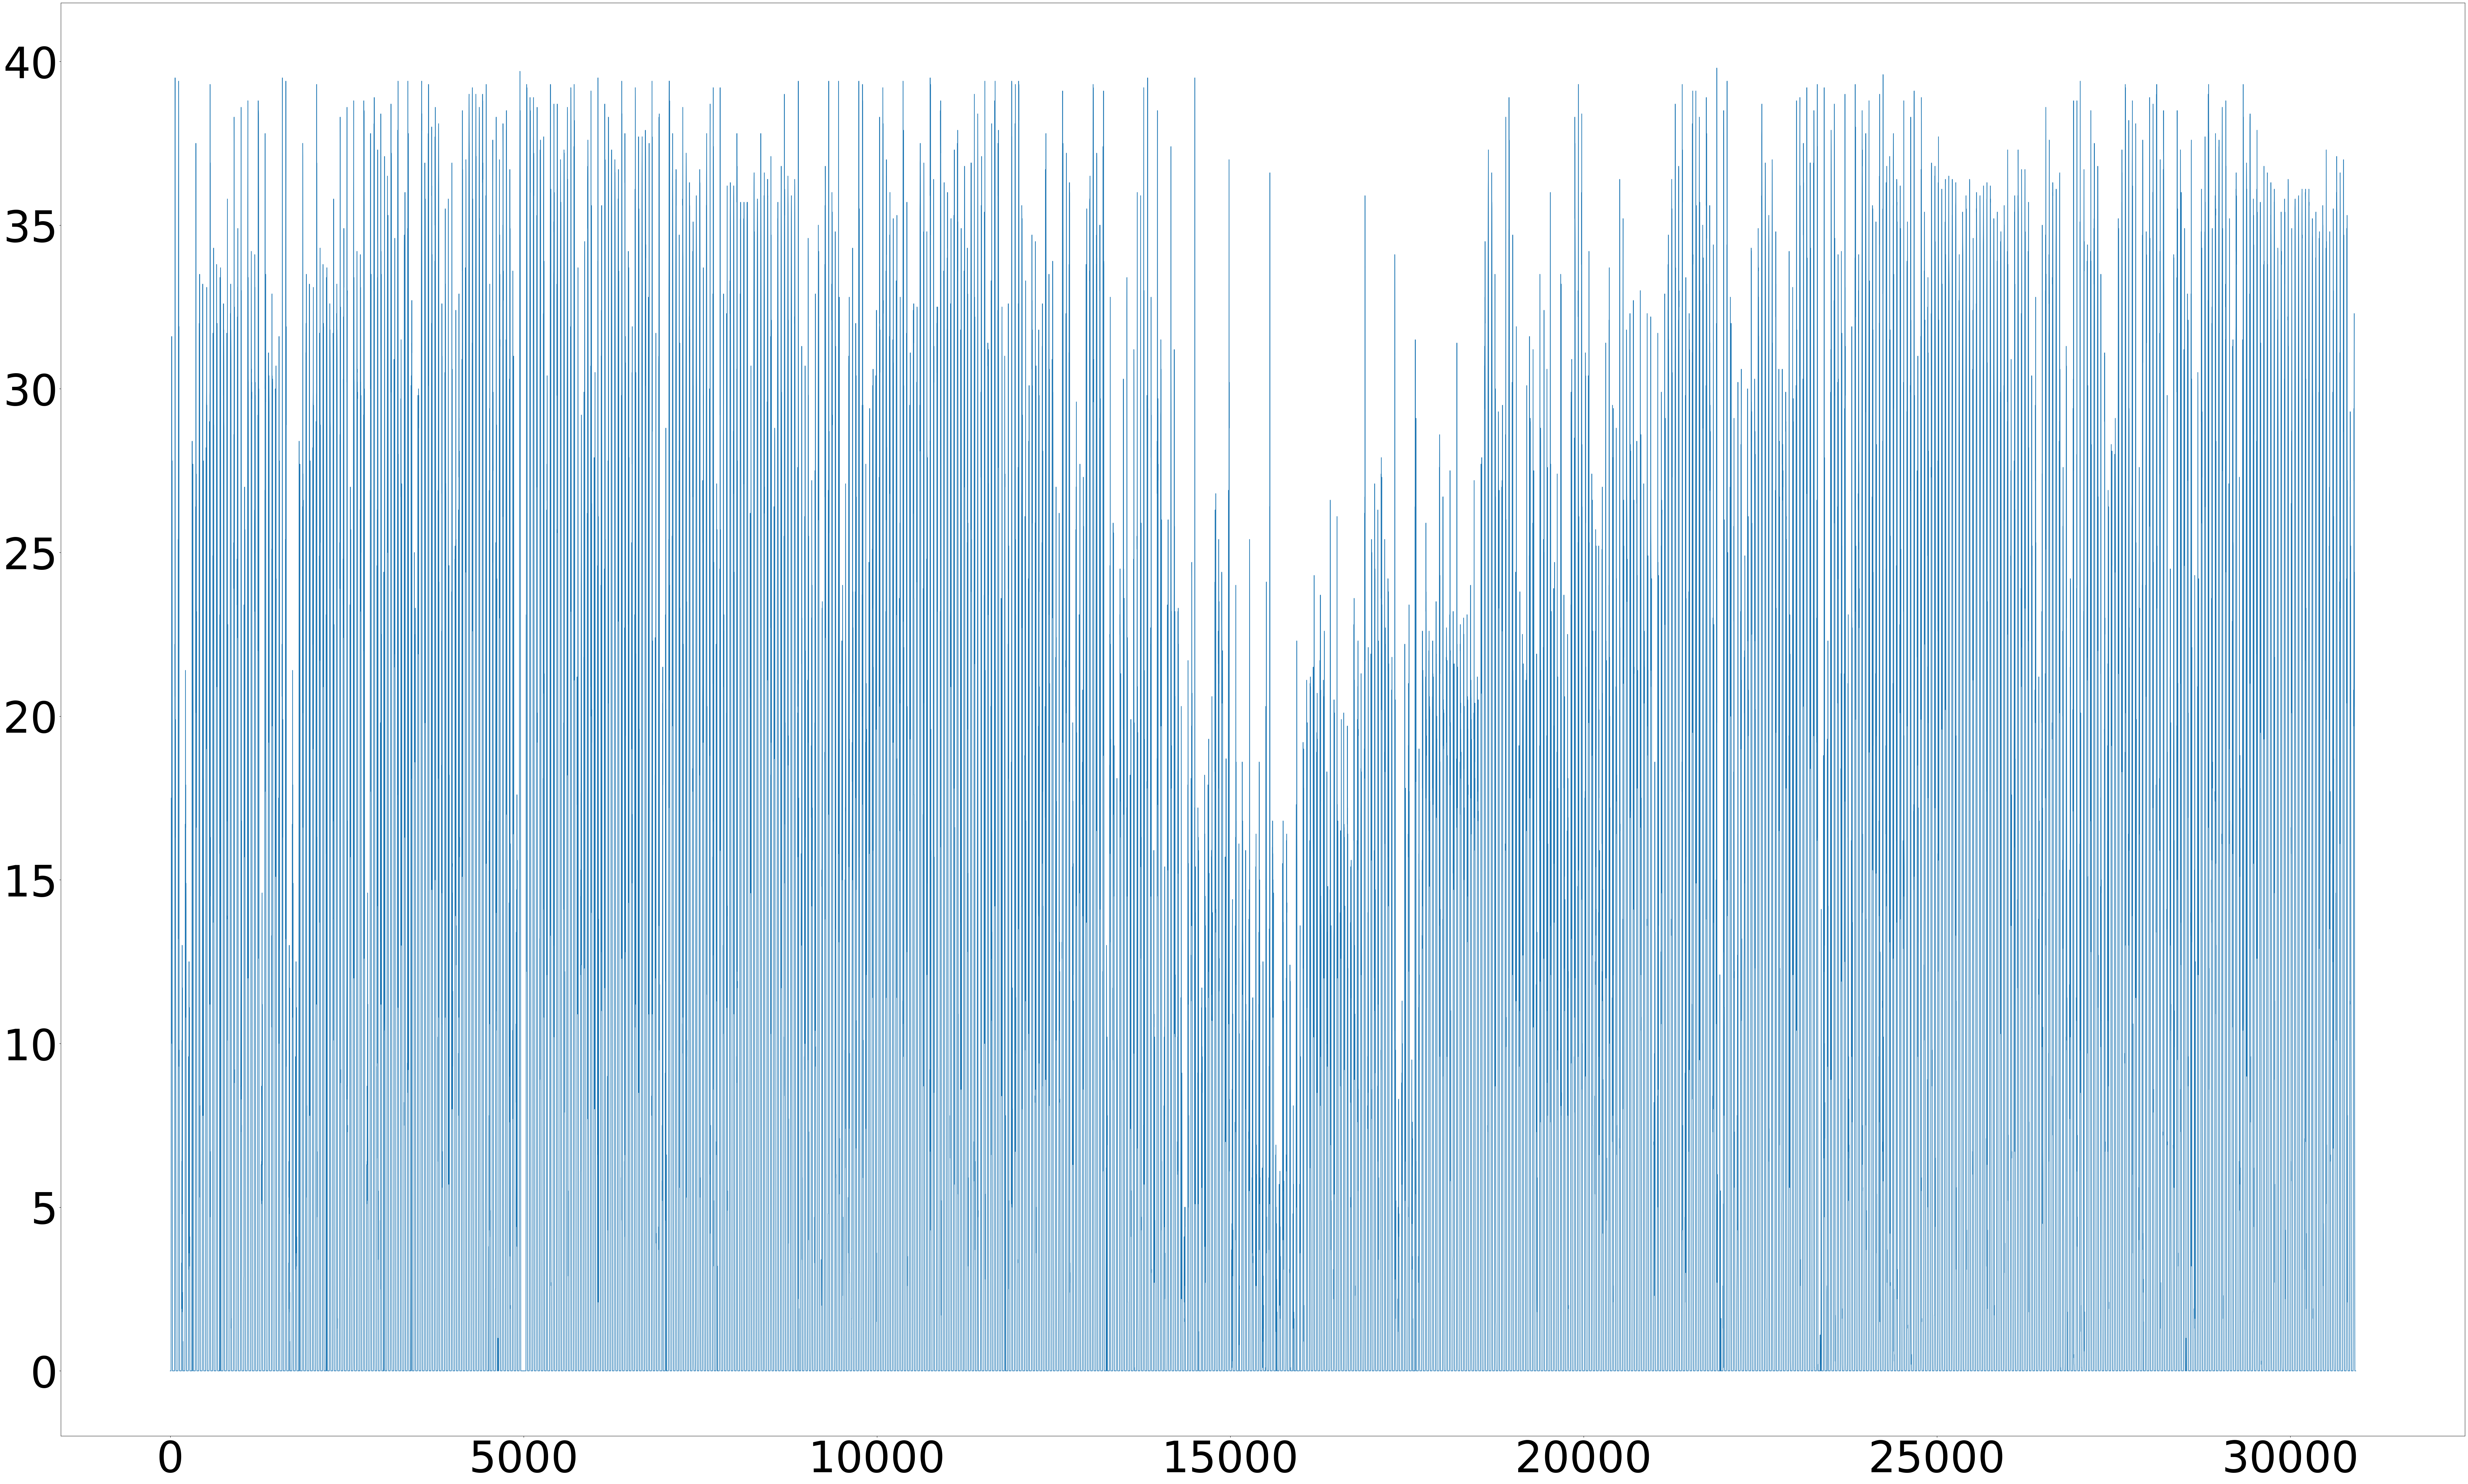

In [6]:
dataset = concatenated_df_arr.astype('float64')
print(dataset)
dataset = np.reshape(dataset, (-1, 1))

# Preprocessing: replacing all negative & NaN values in the dataset with 0
dataset[dataset<0] = 0
dataset[np.isnan(dataset)] = 0

# Plot how dataset looks like
print(dataset.shape)
plt.clf()
plt.figure(figsize=(100,60))
plt.rcParams.update({'font.size': 100})
plt.plot(dataset)
# plt.ylim(0, 80) # set custom limits for the y-axis
plt.show()

### 3.2. Normalization

Scaling the data to a range between 0 and 1 is a common technique used in machine learning to normalize the data. This is done to ensure that all features are on a similar scale and to prevent any one feature from dominating the others. In this case, the MinMaxScaler is used to scale the data to a range between 0 and 1 so that all features are on the same scale. This is important because the LSTM model used for time series prediction is sensitive to the scale of the input data. By scaling the data, we can ensure that the LSTM model performs well and produces accurate predictions.

In [7]:
print(dataset) # check dataset before scaling

# Create a scaler object that will scale data to a range between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
# Use the scaler object created previously to scale our whole dataset
dataset = scaler.fit_transform(dataset)

print(dataset) # check how dataset is after scaling

[[0.]
 [0.]
 [0.]
 ...
 [0.]
 [0.]
 [0.]]
[[0.]
 [0.]
 [0.]
 ...
 [0.]
 [0.]
 [0.]]


### 3.3. Standardization

In [8]:
# Standardization function based on the formula in the journal "A Simplified LSTM Neural Networks for One Day-Ahead Solar Power Forecasting" by Chun-Hung Liu, Jyh-Cherng Gu, and Ming-Ta Yang
def standardize_data(data):
    mean = np.mean(data)
    std_dev = np.std(data)
    standardized_data = (data - mean) / std_dev
    return standardized_data

# Apply standardized function above to existed dataset after normalization
standardized_data = standardize_data(dataset)
print(standardized_data)

[[-0.70570347]
 [-0.70570347]
 [-0.70570347]
 ...
 [-0.70570347]
 [-0.70570347]
 [-0.70570347]]


In [22]:
# Plot data after normalized & standardized with PDF function
import matplotlib.pyplot as plt
import scipy.stats as stats

# Assuming you have already standardized your data (replace with your actual standardized data)
# Example: standardized_data = standardize_data(dataset)

# Create a probability plot (quantile-quantile plot) against the theoretical normal distribution
stats.probplot(standardized_data, dist="norm", plot=plt)

# Add labels and title
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.title("Probability Plot (Q-Q Plot) for Standardized Data")

# Show the plot
plt.grid(True)
plt.show()

ValueError: all the input array dimensions for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 30928 and the array at index 1 has size 1

### 3.4. Data Split

In [9]:
# After scaling our dataset, split them into train and test sets

# Calculates the size of the training set based on the ratio of training to testing data (current ratio = 0.8)
train_size = int(len(dataset) * TRAIN_TEST_RATIO)
# Calculates the size of the testing set based on the size of the training data
test_size = len(dataset) - train_size
# Splits the dataset into training and testing sets
train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]

print(len(train), len(test))

24742 6186


The function creates a dataset for time series prediction by using a sliding window approach with a fixed number of time steps. The input data is split into input (X) and output (Y) components, where X is a 3D array of shape (samples, time steps, features) and Y is a 2D array of shape (samples, features). By using a sliding window approach with a fixed number of time steps, we can ***ensure that the model has access to enough historical data to make accurate predictions***.

In [10]:
# Convert an array of values into a dataset matrix
def create_dataset(dataset, look_back=1):
	dataX, dataY = [], []
	for i in range(len(dataset)-look_back-1):
		a = dataset[i:(i+look_back), 0]
		dataX.append(a)
		dataY.append(dataset[i + look_back, 0])
	return np.array(dataX), np.array(dataY)
# X is a 3D array of shape (samples, time steps, features) and Y is a 2D array of shape (samples, features)

In [11]:
# Reshape into X=t and Y=t+1

# Creates a dataset for training & testing by using a sliding window approach with a fixed number of time steps
trainX, trainY = create_dataset(train, TIME_STEP)
testX, testY = create_dataset(test, TIME_STEP)

print(trainX.shape)
print(testX.shape)

(24721, 20)
(6165, 20)


In [12]:
# Reshape input to be [samples, time steps, features]

# Reshape training & testing data to be compatible with the input shape of the LSTM model
trainX = np.reshape(trainX, (trainX.shape[0], TIME_STEP, 1))
testX = np.reshape(testX, (testX.shape[0], TIME_STEP, 1))

print(trainX.shape)
print(testX.shape)

(24721, 20, 1)
(6165, 20, 1)


## IV. TRAINING MODELS

Depending on the model type input in the Hyperparameters section at the beginning, it will add different layers for different model types

In [13]:
# Create and fit the LSTM network for time series prediction

# Creates an early stopping callback that stops training when the loss stops improving
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='loss', 
                                min_delta=0.00001, 
                                patience=10, 
                                verbose=0, 
                                mode='auto', 
                                baseline=None, 
                                restore_best_weights=True)

# Creates a log directory for TensorBoard
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
# Creates a TensorBoard callback that logs the training progress
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
# Create sequential model
model = Sequential()
# Check the model type and adds the appropriate layers to the model.
if MODEL_TYPE == "LSTM":
    # Adds an LSTM layer with 32 units to the model
    model.add(LSTM(32, input_shape=(TIME_STEP, 1), return_sequences=True))
    # Adds another LSTM layer with 32 units to the model
    model.add(LSTM(32, input_shape=(TIME_STEP, 1)))
    # Adds a dense layer with one unit to the model
    model.add(Dense(1)) 
# Add layers to the model for other different model types
elif MODEL_TYPE == "CNN":
    model.add(Conv1D(32, (3), activation='relu', input_shape=(TIME_STEP,1)))
    # model.add(layers.MaxPooling1D((2)))
    model.add(Conv1D(64, (3), activation='relu'))
    # model.add(layers.MaxPooling1D((2)))
    model.add(Conv1D(64, (3), activation='relu'))
    model.add(MaxPooling1D((2)))
    model.add(Flatten())
    model.add(Dense(64, activation='relu'))
    model.add(Dense(1))
elif MODEL_TYPE == "CNN_LSTM":
    model.add(
        Conv1D(6, (3), activation="relu", input_shape=(TIME_STEP, 1))
    )
    model.add(LSTM(300, "relu", input_shape=(TIME_STEP, 1)))
    model.add(Dense(1))
elif MODEL_TYPE == "CNN_LSTM_DNN":
    model.add(
        Conv1D(64, (5), activation="relu", input_shape=(TIME_STEP, 1))
    )
    model.add(
        LSTM(
            32, "relu", input_shape=(TIME_STEP, 1), return_sequences=True
        )
    )
    model.add(LSTM(32, "relu", input_shape=(TIME_STEP, 1)))
    model.add(Dense(16))
    model.add(Dense(8))
    model.add(Dense(1))
elif MODEL_TYPE == "LSTM_DNN":
    model.add(
        LSTM(
            32, "relu", input_shape=(TIME_STEP, 1), return_sequences=True
        )
    )
    model.add(Dropout(0.2))
    model.add(
        LSTM(
            32, "relu", input_shape=(TIME_STEP, 1), return_sequences=True
        )
    )
    model.add(LSTM(32, "relu", input_shape=(TIME_STEP, 1)))
    model.add(Dense(16))
    model.add(Dense(8))
    model.add(Dense(1))
elif MODEL_TYPE == "LSTM_DNN2":
    model.add(LSTM(300, "relu", input_shape=(TIME_STEP, 1)))
    model.add(Dense(16))
    model.add(Dense(1))
elif MODEL_TYPE == "LSTM_DNN3":
    model.add(LSTM(300, "relu", input_shape=(TIME_STEP, 1), return_sequences=True))
    model.add(LSTM(300, "relu", input_shape=(TIME_STEP, 1)))
    model.add(Dense(32))
    model.add(Dense(1))
elif MODEL_TYPE == "LSTM_DNN4":
    model.add(LSTM(300, "relu", input_shape=(TIME_STEP, 1), return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(300, "relu", input_shape=(TIME_STEP, 1)))
    model.add(Dense(32))
    model.add(Dense(1))
elif MODEL_TYPE == "LSTM_DNN5":
    model.add(LSTM(300, "relu", input_shape=(TIME_STEP, 1)))
    model.add(Dense(1))

In [14]:
# Start training
model.summary()
MODEL_JSON = model.to_json()
# Configure model's loss function & optimizer function
model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(trainX, trainY, epochs=EPOCH_SIZE, batch_size=BATCH_SIZE, verbose=2, callbacks=[early_stopping, tensorboard_callback])
%tensorboard --logdir logs/fit

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 20, 32)            4352      
                                                                 
 lstm_1 (LSTM)               (None, 32)                8320      
                                                                 
 dense (Dense)               (None, 1)                 33        
                                                                 
Total params: 12,705
Trainable params: 12,705
Non-trainable params: 0
_________________________________________________________________
Epoch 1/1000
773/773 - 41s - loss: 0.0148 - 41s/epoch - 53ms/step
Epoch 2/1000
773/773 - 30s - loss: 0.0088 - 30s/epoch - 39ms/step
Epoch 3/1000
773/773 - 32s - loss: 0.0081 - 32s/epoch - 41ms/step
Epoch 4/1000
773/773 - 35s - loss: 0.0081 - 35s/epoch - 45ms/step
Epoch 5/1000
773/773 - 30s - loss: 0.0079 - 30s/epoc

UsageError: Line magic function `%tensorboard` not found.


In [15]:
# Save model
version = 0
for dir in os.scandir(f"./Saved Model/"):
    if dir.is_dir():
        version = int(dir.name) if int(dir.name) > version else version
version += 1
model.save(f"./Saved Model/{version}")

INFO:tensorflow:Assets written to: ./Saved Model/18\assets


INFO:tensorflow:Assets written to: ./Saved Model/18\assets


## V. PREDICTION

### 5.1. SCORES
1. **RMSE (Root Mean Squared Error):** 
    * Lower RMSE values are generally better. A lower RMSE indicates that your model's predictions are closer to the true values.
    * However, whether a particular RMSE is good or not depends on the scale of your data. 
2. **RMSPE (Root Mean Squared Percentage Error):** usually expressed as a percentage
3. **MAE (Mean Absolute Error):** lower MAE values are better. MAE measures the average magnitude of errors, and a lower MAE indicates that the model's predictions are closer to the true values.
4. **MAPE (Mean Absolute Percentage Error):** the average percentage difference between predictions and their intended targets in the dataset. *The lower the value for MAPE, the better the machine learning model* is at predicting values.

#### 5.1.1. Approach 1
The condition before using Approach 1: get rid of all zero values in the data *(negatives values are already removed at the beginning)*

In [ ]:
# Make predictions on training & testing data
train_predict = model.predict(trainX)
test_predict = model.predict(testX)

# Invert predictions
# train_predict = scaler.inverse_transform(train_predict)
# train_true = scaler.inverse_transform([trainY])
# test_predict = scaler.inverse_transform(test_predict)
# test_true = scaler.inverse_transform([testY])
train_predict = train_predict
train_true = np.reshape(trainY,(1,-1))
test_predict = test_predict
test_true = np.reshape(testY,(1,-1))

In [ ]:
print(train_true)


In [ ]:
print(train_predict[:,0])

In [ ]:
# Check if train_true[0] and train_predict[:, 0] have the same shape
assert train_true[0].shape == train_predict[:, 0].shape, "Shapes of train_true[0] and train_predict[:, 0] do not match"

print("Shapes match!")  # This line will only be executed if the shapes match

In [ ]:
# Calculate Root Mean Squared Error (RMSE) - Approach 1
# RMSE & RMSPE for Training data
trainScore = np.sqrt(mean_squared_error(train_true[0], train_predict[:, 0]))
train_score_percentage = np.sqrt(
    np.mean(
        np.square(((train_true[0] - train_predict[:, 0]) / train_true[0])),
        axis=0,
    )
)
#output:
train_score_output = "Train Score: %.4f RMSE" % (trainScore)
train_score_percentage_output = (
    "Train RMSPE: %.4f RMSPE" % train_score_percentage
)

# RMSE & RMSPE for Testing data:
testScore = np.sqrt(mean_squared_error(test_true[0], test_predict[:, 0]))
test_score_percentage = np.sqrt(
    np.mean(
        np.square(((test_true[0] - test_predict[:, 0]) / test_true[0])),
        axis=0,
    )
)
#output:
test_score_percentage_output = "Test RMSPE: %.4f RMSPE" % test_score_percentage
test_score_output = "Test Score: %.4f RMSE" % (testScore)

print(train_score_output)
print(test_score_output)
print(train_score_percentage_output)
print(test_score_percentage_output)


# Calculate Mean Absolute Error MAE 
from sklearn.metrics import mean_absolute_error as mae
trainScore_mae = mae(train_true[0], train_predict[:, 0])
testScore_mae = mae(test_true[0], test_predict[:, 0])
train_mae_output = "Train MAE: %.4f MAE" % (trainScore_mae)
test_mae_output = "Test MAE: %.4f MAE" % (testScore_mae)
print(train_mae_output)
print(test_mae_output)

In [ ]:
# Calculate Mean Absolute Percentage Error (MAPE):
from sklearn.metrics import mean_absolute_percentage_error
# # Calculate the absolute percentage errors
# train_absolute_percentage_error = np.abs((train_true[0] - train_predict[:, 0]) / train_true[0])
# test_absolute_percentage_error = np.abs((test_true[0] - test_predict[:, 0]) / test_true[0])
# # Calculate the mean of the absolute percentage errors
# train_mape = np.mean(train_absolute_percentage_error)
# test_mape = np.mean(test_absolute_percentage_error)


# Calculate MAPE with a small constant added to the denominator
train_mape = mean_absolute_percentage_error(train_true[0], train_predict[:, 0])
test_mape = mean_absolute_percentage_error(test_true[0], test_predict[:, 0])
# Format the results as strings
train_mape_output = "Train MAPE: %.4f MAPE" % (train_mape * 100)
test_mape_output = "Test MAPE: %.4f MAPE" % (test_mape * 100)
print(train_mape_output)
print(test_mape_output)

In [ ]:
# Save results into info.md of each Model has been run for later check
rmse_file = open(
    f"./Saved Model/{version}/info.md", "w"
)
rmse_file.write(
    train_score_output
    + "\n"
    + test_score_output
    + "\n"
    + train_score_percentage_output
    + "\n"
    + test_score_percentage_output
    + "\n"
    + train_mae_output
    + "\n"
    + test_mae_output
    + "\n"
    + train_mape_output
    + "\n"
    + test_mape_output
    + "\n"
    + to_string()
)
rmse_file.close()

#### 5.1.2. Approach 2
This is the 2nd approach for calculating RMSPE by adding a small constant (e.g., 1e-6) to the denominator to prevent division by zero. Run this approach only **when the data contains 0** *OR* **the result is still = "inf" but there are no zero values left in the data** 

In [16]:
# Make predictions on training & testing data
train_predict = model.predict(trainX)
test_predict = model.predict(testX)

# Invert predictions
# train_predict = scaler.inverse_transform(train_predict)
# train_true = scaler.inverse_transform([trainY])
# test_predict = scaler.inverse_transform(test_predict)
# test_true = scaler.inverse_transform([testY])
train_predict = train_predict
train_true = np.reshape(trainY,(1,-1))
test_predict = test_predict
test_true = np.reshape(testY,(1,-1))

193/193 [==============================] - 2s 12ms/step


In [17]:
# Calculate Root Mean Squared Error (RMSE) - Approach 2
# RMSE & RMSPE for Training Data
train_error = train_true[0] - train_predict[:, 0]
trainScore = np.sqrt(mean_squared_error(train_true[0], train_predict[:, 0]))
train_score_percentage = np.sqrt(
    np.mean(np.square(train_error / (train_true[0] + 1e-6)))
)
#output: 
train_score_output = "Train Score: %.4f RMSE" % (trainScore)
train_score_percentage_output = (
    "Train RMSPE: %.4f RMSPE" % train_score_percentage
)

# RMSE & RMSPE for Testing data:
test_error = test_true[0] - test_predict[:, 0]
testScore = np.sqrt(mean_squared_error(test_true[0], test_predict[:, 0]))
test_score_percentage = np.sqrt(
    np.mean(np.square(test_error / (test_true[0] + 1e-6)))
)
#output: 
test_score_percentage_output = "Test RMSPE: %.4f RMSPE" % test_score_percentage
test_score_output = "Test Score: %.4f RMSE" % (testScore)

print(train_score_output)
print(test_score_output)
print(train_score_percentage_output)
print(test_score_percentage_output)


# Calculate Mean Absolute Error (MAE) 
from sklearn.metrics import mean_absolute_error as mae
trainScore_mae = mae(train_true[0], train_predict[:, 0])
testScore_mae = mae(test_true[0], test_predict[:, 0])
train_mae_output = "Train MAE: %.4f MAE" % (trainScore_mae)
test_mae_output = "Test MAE: %.4f MAE" % (testScore_mae)
print(train_mae_output)
print(test_mae_output)

Train Score: 0.0469 RMSE
Test Score: 0.1044 RMSE
Train RMSPE: 7481.9503 RMSPE
Test RMSPE: 5949.4325 RMSPE
Train MAE: 0.0234 MAE
Test MAE: 0.0492 MAE


In [20]:
from sklearn.metrics import mean_absolute_error

# Function to calculate Root Mean Squared Error (RMSE) and Root Mean Squared Percentage Error (RMSPE)
def calculate_rmse_rmspe(true, predict):
    error = true - predict
    rmse = np.sqrt(mean_squared_error(true, predict))
    rmspe = np.sqrt(np.mean(np.square(error / (true + 1e-6))))
    return rmse, rmspe

# Function to calculate Mean Absolute Error (MAE)
def calculate_mae(true, predict):
    return mean_absolute_error(true, predict)

# Calculate metrics for training data
train_rmse, train_rmspe = calculate_rmse_rmspe(train_true[0], train_predict[:, 0])
train_mae = calculate_mae(train_true[0], train_predict[:, 0])

# Calculate metrics for testing data
test_rmse, test_rmspe = calculate_rmse_rmspe(test_true[0], test_predict[:, 0])
test_mae = calculate_mae(test_true[0], test_predict[:, 0])

# Print the results
print(f"Train RMSE: {train_rmse:.4f} RMSE")
print(f"Test RMSE: {test_rmse:.4f} RMSE")
print(f"Train RMSPE: {train_rmspe:.4f} RMSPE")
print(f"Test RMSPE: {test_rmspe:.4f} RMSPE")
print(f"Train MAE: {train_mae:.4f} MAE")
print(f"Test MAE: {test_mae:.4f} MAE")

Train RMSE: 0.0469 RMSE
Test RMSE: 0.1044 RMSE
Train RMSPE: 7481.9503 RMSPE
Test RMSPE: 5949.4325 RMSPE
Train MAE: 0.0234 MAE
Test MAE: 0.0492 MAE


In [18]:
# Calculate Mean Absolute Percentage Error (MAPE):

# Approach 1: 
# # Calculate the absolute percentage errors
# train_absolute_percentage_error = np.abs(train_error / (train_true[0] + 1e-6))
# test_absolute_percentage_error = np.abs(test_error / (test_true[0] + 1e-6))
# # Calculate the mean of the absolute percentage errors
# train_mape = np.mean(train_absolute_percentage_error)
# test_mape = np.mean(test_absolute_percentage_error)


# Approach 2: both generate same result
# from sklearn.metrics import mean_absolute_percentage_error
# # Define a small constant
# epsilon = 1e-6
# # Calculate MAPE with a small constant added to the denominator
# train_mape = mean_absolute_percentage_error(train_true[0], train_predict[:, 0] + epsilon)
# test_mape = mean_absolute_percentage_error(test_true[0], test_predict[:, 0] + epsilon)


# Approach 3: similar to Approach 1
# Calculate the mean absolute true value
mean_abs_true_value = np.mean(np.abs(train_true[0]))

# Calculate the scaling factor
train_scaling_factor = mean_abs_true_value / 1e-6

# Calculate the absolute percentage errors
train_absolute_percentage_error = np.abs(train_error / train_scaling_factor)
test_absolute_percentage_error = np.abs(test_error / train_scaling_factor)      # Use the same scaling factor for test data

# Calculate the mean of the absolute percentage errors
train_mape = np.mean(train_absolute_percentage_error)
test_mape = np.mean(test_absolute_percentage_error)


# Format the results as strings
train_mape_output = "Train MAPE: %.4f MAPE" % (train_mape * 100)    # result in percent
test_mape_output = "Test MAPE: %.4f MAPE" % (test_mape * 100)       # result in percent

print(train_mape_output)
print(test_mape_output)

Train MAPE: 0.0000 MAPE
Test MAPE: 0.0000 MAPE


In [19]:
# Save results into info.md of each Model has been run for later check
rmse_file = open(
    f"./Saved Model/{version}/info.md", "w"
)
rmse_file.write(
    train_score_output
    + "\n"
    + test_score_output
    + "\n"
    + train_score_percentage_output
    + "\n"
    + test_score_percentage_output
    + "\n"
    + train_mae_output
    + "\n"
    + test_mae_output
    + "\n"
    + train_mape_output
    + "\n"
    + test_mape_output
    + "\n"
    + to_string()
)
rmse_file.close()

### 5.2. PLOT

<Figure size 640x480 with 0 Axes>

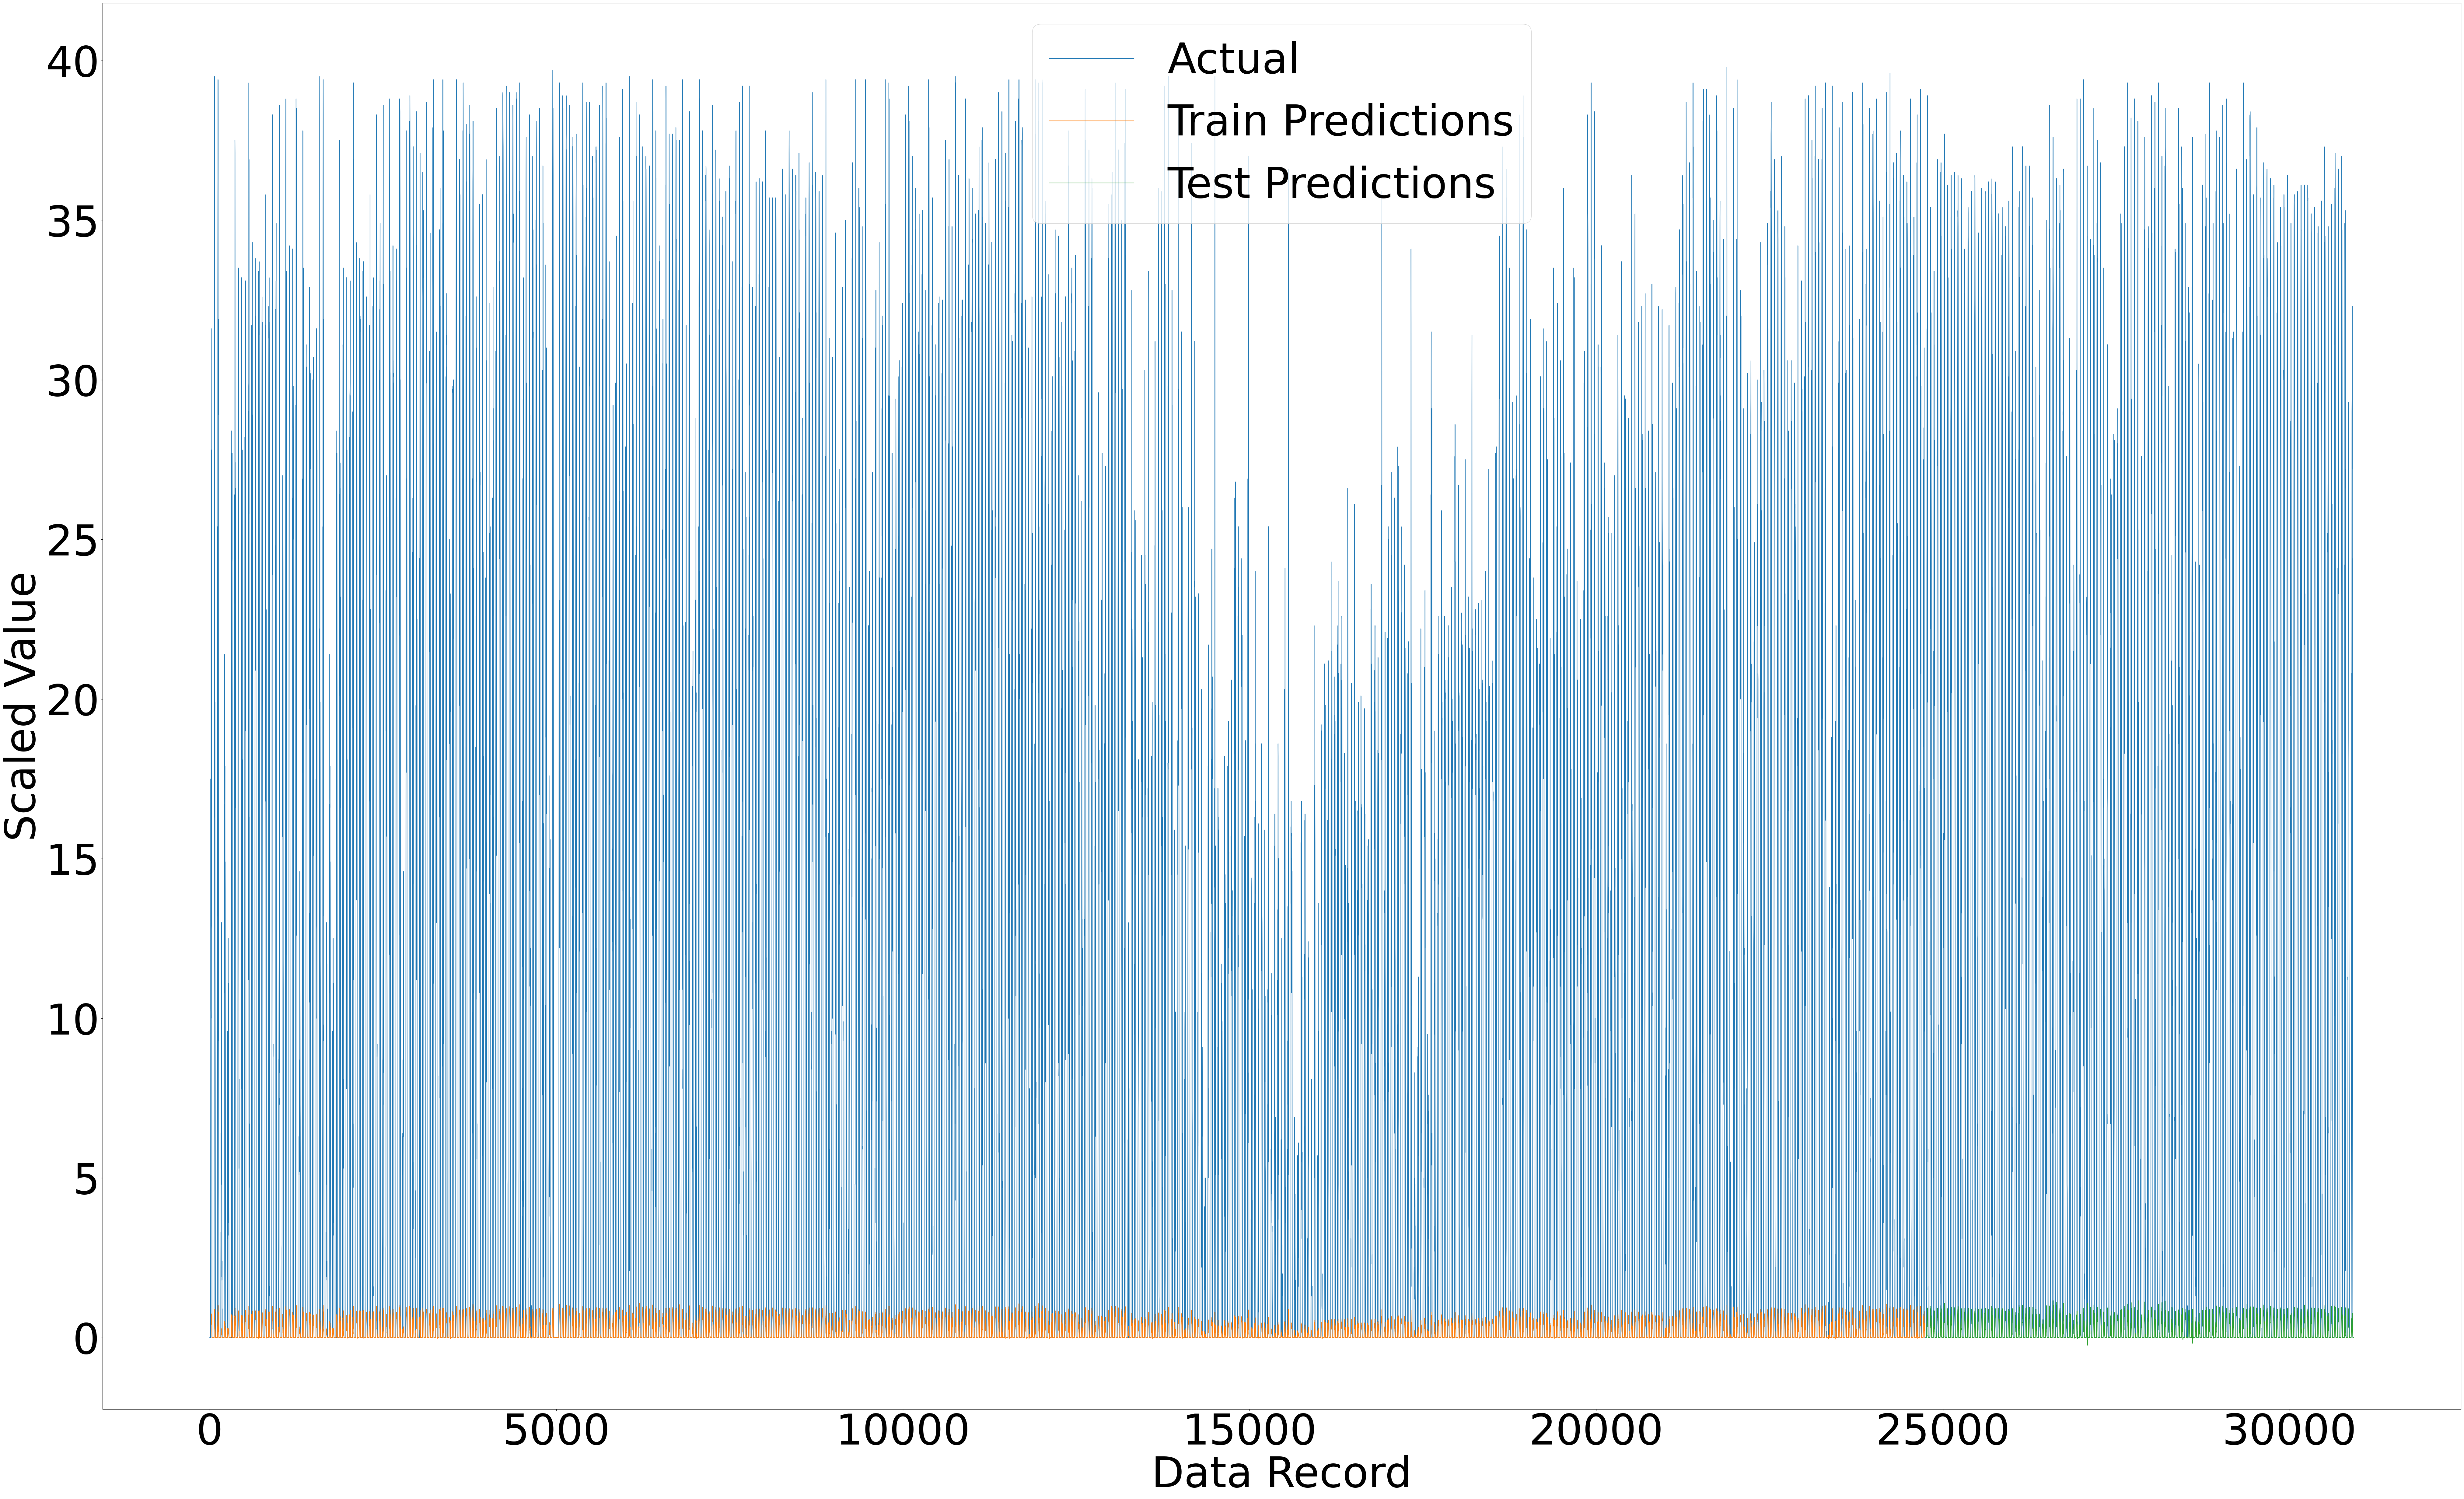

In [21]:
# Shift train predictions for plotting
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[TIME_STEP:len(train_predict)+TIME_STEP, :] = train_predict
# Shift test predictions for plotting
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(train_predict)+(TIME_STEP*2)+1:len(dataset)-1, :] = test_predict
# Plot baseline and predictions
plt.clf()
plt.figure(figsize=(100,60))
plt.rcParams.update({'font.size': 100})
plt.plot(scaler.inverse_transform(dataset), label='Actual')
plt.plot(trainPredictPlot, label='Train Predictions')
plt.plot(testPredictPlot, label='Test Predictions')

# Add axis labels and legend
plt.xlabel('Data Record')
plt.ylabel('Scaled Value')
plt.legend(['Actual', 'Train Predictions', 'Test Predictions'])
# plt.ylim(0, 80) # set custom limits for the y-axis

# Save the plot to a file
plt.savefig(f"Saved Model/{version}/predict.png")
plt.show()